# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?



# Lab Work
## Question #1
Between years at the company, hours worked, and focus, it appears that the focus score has the strongest linear relationship with an R-squared value of 0.678. Our data points are following the line more closely while years at the company and hours worked show almost no linear relationship with productivity.

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

df = pd.read_csv('Employee_productivity.csv')

df.head()


,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


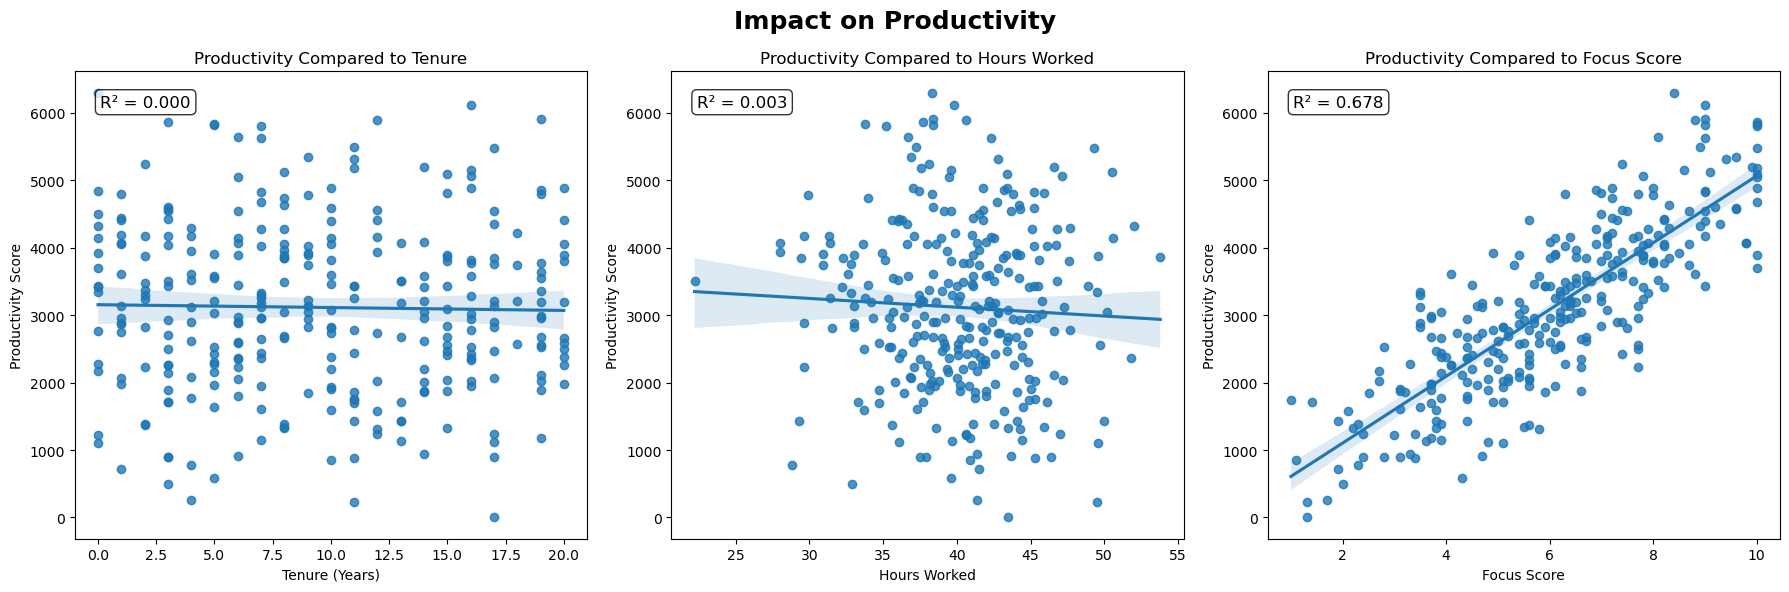

In [111]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Impact on Productivity', fontsize=18, fontweight='bold')

# First subplot - Tenure vs Productivity
sns.regplot(x='YearsAtCompany', y='ProductivityScore', data=df, ax=axes[0])
axes[0].set_title('Productivity Compared to Tenure')
axes[0].set_xlabel('Tenure (Years)')
axes[0].set_ylabel('Productivity Score')

x1 = sm.add_constant(df['YearsAtCompany'])
y1 = df['ProductivityScore']
model1 = sm.OLS(y1, x1).fit()

axes[0].text(0.05, 0.95, f'R² = {model1.rsquared:.3f}', 
             transform=axes[0].transAxes, 
             fontsize=12, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
             verticalalignment='top')

# Second subplot - Hours Worked vs Productivity
sns.regplot(x='HoursWorked', y='ProductivityScore', data=df, ax=axes[1])
axes[1].set_title('Productivity Compared to Hours Worked')
axes[1].set_xlabel('Hours Worked')
axes[1].set_ylabel('Productivity Score')

x2 = sm.add_constant(df['HoursWorked'])
y2 = df['ProductivityScore']
model2 = sm.OLS(y2, x2).fit()

axes[1].text(0.05, 0.95, f'R² = {model2.rsquared:.3f}', 
             transform=axes[1].transAxes, 
             fontsize=12, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
             verticalalignment='top')

# Third subplot - Focus Score vs Productivity
sns.regplot(x='FocusScore', y='ProductivityScore', data=df, ax=axes[2])
axes[2].set_title('Productivity Compared to Focus Score')
axes[2].set_xlabel('Focus Score')
axes[2].set_ylabel('Productivity Score')

x3 = sm.add_constant(df['FocusScore'])
y3 = df['ProductivityScore']
model3 = sm.OLS(y3, x3).fit()

axes[2].text(0.05, 0.95, f'R² = {model3.rsquared:.3f}', 
             transform=axes[2].transAxes, 
             fontsize=12, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
             verticalalignment='top')

plt.tight_layout()
plt.show()

## Question 2

C:\Users\davin\AppData\Local\Temp\ipykernel_26344\3996939685.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[0].text(0.05, 0.95, f'R² = {model1.rsquared:.3f}\np-value = {model1.pvalues[1]:.4f}',
C:\Users\davin\AppData\Local\Temp\ipykernel_26344\3996939685.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[1].text(0.05, 0.95, f'R² = {model2.rsquared:.3f}\np-value = {model2.pvalues[1]:.4f}',
C:\Users\davin\AppData\Local\Temp\ipykernel_26344\3996939685.py:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (co

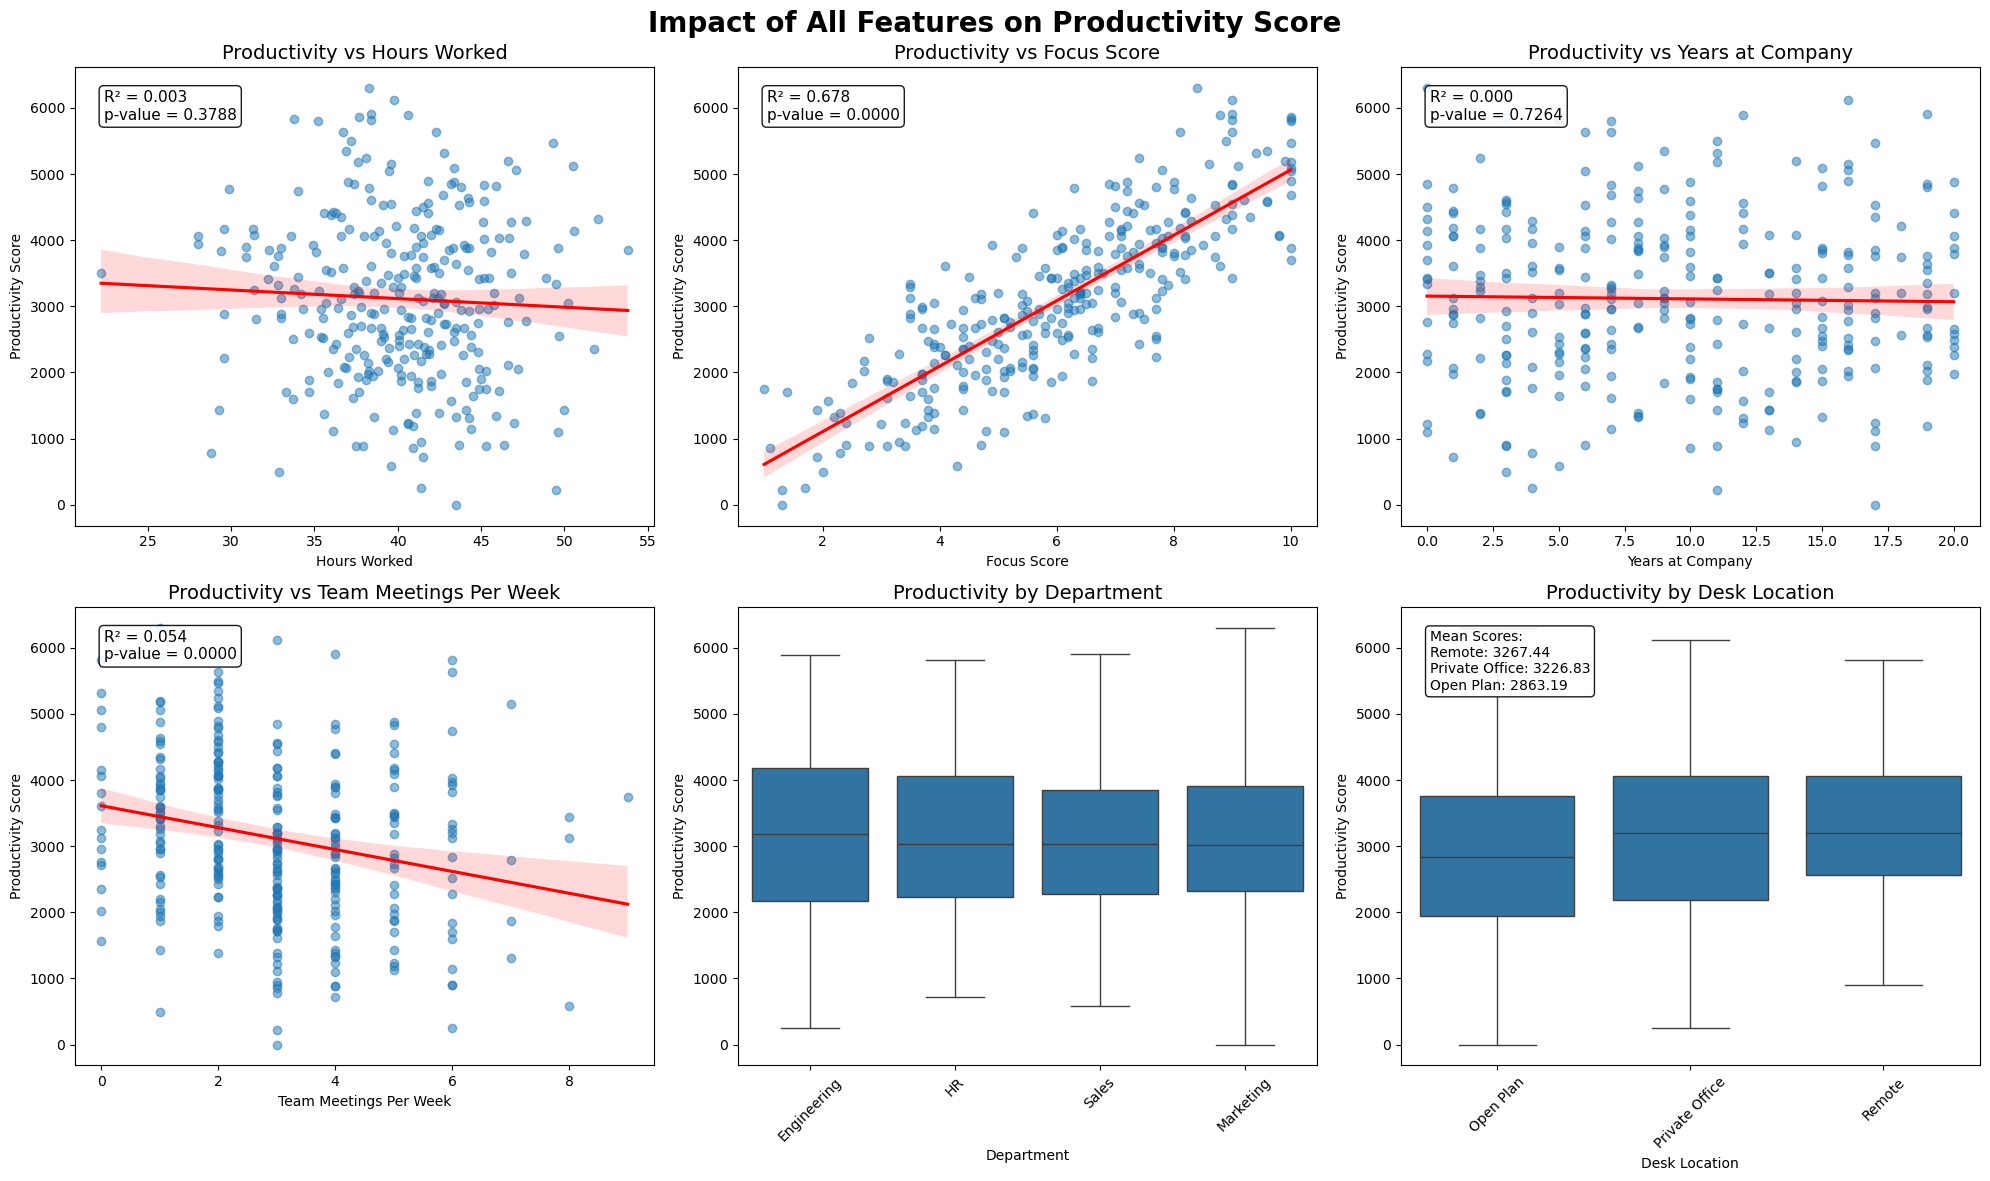

In [113]:
# Read the data
df = pd.read_csv('Employee_productivity.csv')

# Create a 2x3 subplot grid for all features
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Impact of All Features on Productivity Score', fontsize=20, fontweight='bold')

# Flatten axes for easier iteration
axes = axes.flatten()

# 1. Hours Worked vs Productivity
sns.regplot(x='HoursWorked', y='ProductivityScore', data=df, ax=axes[0], 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[0].set_title('Productivity vs Hours Worked', fontsize=14)
axes[0].set_xlabel('Hours Worked')
axes[0].set_ylabel('Productivity Score')

# Calculate R² for Hours Worked
x1 = sm.add_constant(df['HoursWorked'])
y1 = df['ProductivityScore']
model1 = sm.OLS(y1, x1).fit()
axes[0].text(0.05, 0.95, f'R² = {model1.rsquared:.3f}\np-value = {model1.pvalues[1]:.4f}', 
             transform=axes[0].transAxes, fontsize=11,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
             verticalalignment='top')

# 2. Focus Score vs Productivity
sns.regplot(x='FocusScore', y='ProductivityScore', data=df, ax=axes[1],
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[1].set_title('Productivity vs Focus Score', fontsize=14)
axes[1].set_xlabel('Focus Score')
axes[1].set_ylabel('Productivity Score')

# Calculate R² for Focus Score
x2 = sm.add_constant(df['FocusScore'])
y2 = df['ProductivityScore']
model2 = sm.OLS(y2, x2).fit()
axes[1].text(0.05, 0.95, f'R² = {model2.rsquared:.3f}\np-value = {model2.pvalues[1]:.4f}', 
             transform=axes[1].transAxes, fontsize=11,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
             verticalalignment='top')

# 3. Years at Company vs Productivity
sns.regplot(x='YearsAtCompany', y='ProductivityScore', data=df, ax=axes[2],
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[2].set_title('Productivity vs Years at Company', fontsize=14)
axes[2].set_xlabel('Years at Company')
axes[2].set_ylabel('Productivity Score')

# Calculate R² for Years at Company
x3 = sm.add_constant(df['YearsAtCompany'])
y3 = df['ProductivityScore']
model3 = sm.OLS(y3, x3).fit()
axes[2].text(0.05, 0.95, f'R² = {model3.rsquared:.3f}\np-value = {model3.pvalues[1]:.4f}', 
             transform=axes[2].transAxes, fontsize=11,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
             verticalalignment='top')

# 4. Team Meetings Per Week vs Productivity
sns.regplot(x='TeamMeetingsPerWeek', y='ProductivityScore', data=df, ax=axes[3],
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[3].set_title('Productivity vs Team Meetings Per Week', fontsize=14)
axes[3].set_xlabel('Team Meetings Per Week')
axes[3].set_ylabel('Productivity Score')

# Calculate R² for Team Meetings
x4 = sm.add_constant(df['TeamMeetingsPerWeek'])
y4 = df['ProductivityScore']
model4 = sm.OLS(y4, x4).fit()
axes[3].text(0.05, 0.95, f'R² = {model4.rsquared:.3f}\np-value = {model4.pvalues[1]:.4f}', 
             transform=axes[3].transAxes, fontsize=11,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
             verticalalignment='top')

# 5. Department vs Productivity (Box Plot)
# Using box plot since Department is categorical
sns.boxplot(x='Department', y='ProductivityScore', data=df, ax=axes[4])
axes[4].set_title('Productivity by Department', fontsize=14)
axes[4].set_xlabel('Department')
axes[4].set_ylabel('Productivity Score')
axes[4].tick_params(axis='x', rotation=45)

# 6. Desk Location vs Productivity (Box Plot)
# Using box plot since Desk Location is categorical
sns.boxplot(x='DeskLocation', y='ProductivityScore', data=df, ax=axes[5])
axes[5].set_title('Productivity by Desk Location', fontsize=14)
axes[5].set_xlabel('Desk Location')
axes[5].set_ylabel('Productivity Score')
axes[5].tick_params(axis='x', rotation=45)

# Calculate mean productivity by desk location
desk_means = df.groupby('DeskLocation')['ProductivityScore'].mean().sort_values(ascending=False)
desk_text = '\n'.join([f'{loc}: {mean:.2f}' for loc, mean in desk_means.items()])
axes[5].text(0.05, 0.95, f'Mean Scores:\n{desk_text}', 
             transform=axes[5].transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
             verticalalignment='top')

plt.tight_layout()
plt.show()

In [98]:
df = pd.read_csv('Employee_productivity.csv')

# Create binary indicator for non-remote workers
df['DeskLocation'] = df['DeskLocation'].map({'Private Office':1, 'Open Plan':1, 'Remote':0})

# Multiple regression: Focus Score + Desk Location predicting Productivity
x4 = sm.add_constant(df[['FocusScore', 'DeskLocation']])
y4 = df['ProductivityScore']
model4 = sm.OLS(y4, x4).fit()

model4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     317.0
Date:                Sun, 21 Sep 2025   Prob (F-statistic):           2.05e-74
Time:                        12:34:33   Log-Likelihood:                -2392.7
No. Observations:                 300   AIC:                             4791.
Df Residuals:                     297   BIC:                             4803.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -32.1310    151.324     -0.212      0.832    -329.935     265.673
FocusScore     500.7777     19.983     25.060      0.000     461.452     540.104
DeskLocation   158.6874     90.413      1.755      0.080     -19.245     336.619
==============================================================================
Omnibus:                        0.893   Durbin-Watson:                   2.044
Prob(Omnibus):                  0.640   Jarque-Bera (JB):                0.962
Skew:                           0.052   Prob(JB):                        0.618
Kurtosis:                       2.743   Cond. No.                         25.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Question 3
Based on the impact each feature in the dataset has on productivity, it appears that focus and desk location have the greatest effects. Open plan desk locations have a lower mean focus and probability scores than remnote and private office desk locations. A model built with focus and remote/non-remote features gives us a R-squared value of 0.681. Since desk lolcation has an effect on focus, I would recommend transistioning employees from an open plan desk to remote for a gain in productivity score.